In [32]:
# before we starting to train ANN 
# we should understand what is ANN 

# ANN is Machine learning model Highly inspired from Human Brain 
# It learns patterns from data by adjusting Mathematical parameters such as weights as biases

# in this project ANN model learn relationship in between patients health features such as glucose , BP , BMI , Age  , Insulin , Skin Thickness , Diabaeticpedegree function 

In [33]:
# now we understood what is ANN so its mathematical parameters,

# weight = weight is nothing but how imp the featur is that tell by weight , it gives importance to features

# bias = bias is the learnable parameter which shifted neurons output , and adding bias give the more flexible model to fit the data

# Activation function - it converts the output coming from neuron to something meaningful , like in our case it converts the probability of diabeties

# there are many Activation function 

# but for now we use only 2 activation function

# 1. ReLU - Rectified linear unit

# formula     f(x) = max(0, x)

# it simply says that if output is negative then return 0 and if input is possitive then return that number (like Kaddane Algo - not all but only idea)


# 2. Sigmoid function

# formula -       σ(x)=1/(1+e^−x)

# what it does - it simply converts raw o/p into 0 to 1 so it is benficial .... suppose raw o/p is 145 then it converts something like 0.95 , if -25 then something like 0.00002


In [34]:
# Now concept of Loss function

# loss function is nothing but the difference between desired output and output coming from ANN

# sometimes ANN is not giving exact desired outputs , there is mistake in that o/p 
# suppose ANN gives o/p is 0.95 thaat is 95% of probability for diabeties but desired output is 0 that mean there is mistake between result

# so after that ANN slighlty changes weights 
# again checks loss
# again changes weight if needed for desired o/p

# Minor error can be handled but larger error should be handled by adjusting weights 1000's of time if needed

# backpropogation cycle
#             Input Data
#              │
#              ▼
#    Forward Propagation
#              │
#              ▼
#       Prediction
#              │
#              ▼
#       Loss Function
#              │
#              ▼
#    Backpropagation
#              │
#              ▼
#      Update Weights
#              │
#              └──────────────┐
#                             │
#                             ▼
#                       Forward Again
#                              │
#                              ▼
#                           Prediction
#                              │
#                              ▼
#                       Loss Function
#                              │
#                              ▼
#                    Backpropagation
#                              │
#                              ▼
#                      Update Weights

# this cycle continues till desired o/p can be obtained





In [35]:
# now question arise that how weights are arranged when backpropogation

# Not too much.

# Not too little.

# This is controlled by a parameter called the Learning Rate

In [36]:
# learning cycle
# Patient Features
#         │
#         ▼
# Multiply by Weights
#         │
#         ▼
# Add Bias
#         │
#         ▼
# Weighted Sum (z)
#         │
#         ▼
# Activation Function
#         │
#         ▼
# Prediction
#         │
#         ▼
# Loss Function
#         │
#         ▼
# Backpropagation
#         │
#         ▼
# Update Weights
#         │
#         ▼
# Repeat

In [37]:
# now we are moving towards the implimentation

# what is tensorflow 
# Tensroflow is a ML framework developed by Google.

# Instead of writing all the mathematics for:

# Forward Propagation
# Backpropagation
# Gradient Descent
# Weight Updates
# -- Tensorflow is work on that , insted of manually mathematical computation tensorflow works this 


In [38]:
import sys
print(sys.version)
print(sys.executable)

3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
C:\Users\RUSHIKESH\miniconda3\envs\ai_project\python.exe


In [39]:
import numpy as np
import pandas as pd


In [40]:
df = pd.read_csv('../datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
cols = [
    "Glucose" ,
    "BloodPressure" ,
    "SkinThickness" ,
    "Insulin",
    "BMI"
    ]

df[cols] = df[cols].replace(0,np.nan)

In [42]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [43]:
df["Glucose"] = df["Glucose"].fillna(
    df["Glucose"].mean()
)
 
df["BloodPressure"] = df["BloodPressure"].fillna(
    df["BloodPressure"].mean()
)

df["BMI"] = df["BMI"].fillna(
    df["BMI"].mean()
)

In [44]:
df["SkinThickness"] = df["SkinThickness"].fillna(
    df["SkinThickness"].median()
)
df["Insulin"] = df["Insulin"].fillna(
    df["Insulin"].median()
)
 

In [45]:
X = df.drop("Outcome", axis=1)
Y = df["Outcome"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# sequential is a strraight pipeline like input layer -> hidden layer 1 -> h . laye 2 -> ... -> o/p layer

# dense is the in simple word each neuron should connected with each layer thats the dense



# first step is to create the model ----- (Before training)
# beccause at the initial stage there is no neurons , no layers so first we build the model
model = Sequential()

model.add(
    Dense(
        units=16,
        activation="relu",
        input_shape=(8,)
    )
)

model.add(
    Dense(
        units=8,
        activation="relu"
    )
)


# O/p layer
model.add(
    Dense(
        units=1,
        activation="sigmoid"
    )
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)



C:\Users\RUSHIKESH\miniconda3\envs\ai_project\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.4277 - loss: 0.7141 - val_accuracy: 0.5772 - val_loss: 0.6711
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5845 - loss: 0.6729 - val_accuracy: 0.6504 - val_loss: 0.6448
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6701 - loss: 0.6444 - val_accuracy: 0.6748 - val_loss: 0.6262
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6864 - loss: 0.6202 - val_accuracy: 0.6748 - val_loss: 0.6072
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6945 - loss: 0.5976 - val_accuracy: 0.6992 - val_loss: 0.5876
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6965 - loss: 0.5771 - val_accuracy: 0.6992 - val_loss: 0.5699
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6986 - loss: 0.5597 - val_accuracy: 0.6911 - val_loss: 0.5543
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7108 - loss: 0.5454 - val_accuracy: 0.

In [49]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [50]:
history.history


{'accuracy': [0.4276985824108124,
  0.5845214128494263,
  0.6700611114501953,
  0.686354398727417,
  0.6945010423660278,
  0.6965376734733582,
  0.6985743641853333,
  0.7107942700386047,
  0.7169042825698853,
  0.723014235496521,
  0.7413442134857178,
  0.7454175353050232,
  0.7515274882316589,
  0.7474541664123535,
  0.7576375007629395,
  0.7617108225822449,
  0.7637474536895752,
  0.7657840847969055,
  0.771894097328186,
  0.7698574066162109,
  0.7698574066162109,
  0.771894097328186,
  0.7678207755088806,
  0.7657840847969055,
  0.7759674191474915,
  0.7739307284355164,
  0.7698574066162109,
  0.771894097328186,
  0.7739307284355164,
  0.7739307284355164,
  0.7820773720741272,
  0.7820773720741272,
  0.790224015712738,
  0.7942973375320435,
  0.7861506938934326,
  0.7963340282440186,
  0.7942973375320435,
  0.7922607064247131,
  0.7922607064247131,
  0.7963340282440186,
  0.7963340282440186,
  0.800407350063324,
  0.800407350063324,
  0.8065173029899597,
  0.8065173029899597,
  0.80

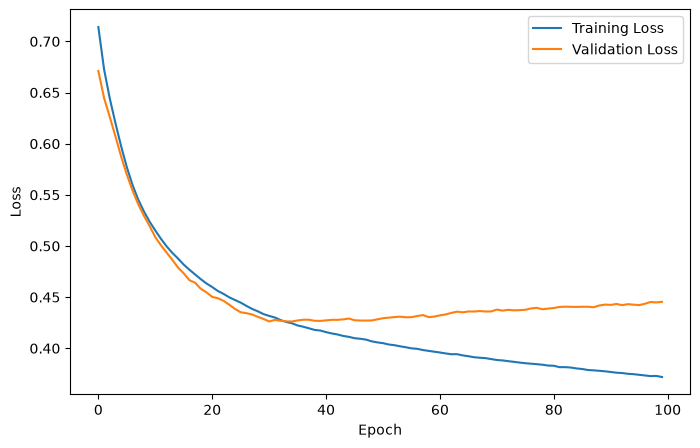

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

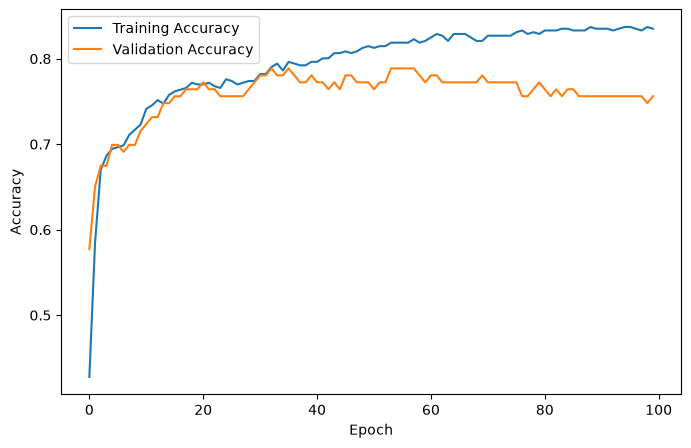

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [53]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7078 - loss: 0.5676
Loss: 0.5676307678222656
Accuracy: 0.7077922224998474


In [54]:
predictions = model.predict(X_test)

print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.6923213 ]
 [0.0692227 ]
 [0.04543295]
 [0.2743129 ]
 [0.3713192 ]
 [0.6675639 ]
 [0.00177519]
 [0.75694835]
 [0.78287494]
 [0.61031246]]


In [55]:
predictions = (predictions > 0.5).astype(int)

print(predictions[:20])
print(y_test[:20])

[[1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]]
668    0
324    0
624    0
690    0
473    0
204    0
97     0
336    0
568    0
148    0
667    1
212    0
199    1
265    0
760    0
356    1
501    0
457    0
604    1
213    1
Name: Outcome, dtype: int64


In [56]:
import numpy as np

print(np.unique(predictions, return_counts=True))

(array([0, 1]), array([96, 58]))


In [57]:
print(y_test.value_counts())

Outcome
0    99
1    55
Name: count, dtype: int64


In [58]:
print(y_train.value_counts())

Outcome
0    401
1    213
Name: count, dtype: int64


In [59]:
print(X_train[:5])

[[-0.52639686 -1.25828206  0.01321033  0.03429766 -0.17561958  0.01501323
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.32735374  0.8068672  -0.56058261 -0.17561958 -0.59935041
   2.41502991  1.48710085]
 [-0.82846011  0.57032714 -2.17095414 -1.15546287 -0.65219306 -0.52719904
   0.54916055 -0.94893896]
 [-1.13052335  1.30177082 -1.8400851   0.03429766 -0.17561958 -1.50845762
  -0.63929127  2.79212217]
 [ 0.68185612  0.40408994  0.64143268  0.98610608  2.60439237  1.99809876
  -0.68682934  1.13909516]]


In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 869 (3.40 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 580 (2.27 KB)

In [61]:
model.get_weights()[0][:5]

array([[ 0.02005995,  0.04998041, -0.42263106,  0.38793248, -0.43429872,
        -0.11557548,  0.13488904,  0.16574709,  0.33984932, -0.35603866,
        -0.05485805, -0.2672122 , -0.7003414 , -0.28355834,  0.453412  ,
         0.02923031],
       [-0.36951175,  0.27239716,  0.14192216, -0.56352645, -0.8332562 ,
         0.19724894,  0.36465412, -0.39380735,  0.07846072, -0.5510341 ,
        -0.02719674,  0.5153582 ,  0.63420653, -0.02195329,  0.14034374,
        -0.55309004],
       [ 0.39550784, -0.53333634,  0.05348071, -0.39128208, -0.05665847,
        -0.44654715, -0.41832054,  0.50374573,  0.2763145 ,  0.2559387 ,
         0.55048805,  0.12498847,  0.25026765, -0.2210286 ,  0.43493992,
         0.42124698],
       [ 0.12946136, -0.60903484, -0.43160656, -0.16841578,  0.20908391,
        -0.6328626 ,  0.02389827,  0.16217296,  0.06868126, -0.05690854,
        -0.36166507,  0.02750273,  0.15130243,  0.2610734 , -0.12917249,
         0.09543688],
       [-0.10284704, -0.15962838, -0